# UFCE3R-30-3 - Big data analytics
# Assessment Template
This notebook has been created for you to write your answers to the assessment questions regarding Python. Please ONLY use this file to answer questions and then upload your answers.

## Marking Guideline for each question
Q2.1-Q2.3

- 0%: no answer, irrelevant or incorrect answer
- 10%-20%: insufficient and/or many mistakes
- 30%-40%: acceptable, but incomplete and/or substantial mistakes and lack of comments for explanation
- 50%-60%: good, substantial answer, with good comments for explanation
- 70%-80%: very good, mostly complete, only minor mistake or issue with concise explanation
- 90%-100%: excellent, complete answer with clear and sufficient explanation


## Question 2.1: Anomaly Detection (30 marks)

In [8]:
# Write the code here with comments for explanation
# Question 2.1: Anomaly Detection
# This code identifies unusual and problematic transactions
# using z-score analysis and rule-based filtering.

import pandas as pd
import numpy as np

# Load only required columns to improve performance
cols = [
    'product_category', 'total_amount',
    'product_rating', 'quantity'
]
df = pd.read_csv("portfolio_sales_data.csv", usecols=cols)

# --------------------------------------------------
# (a) Z-score based anomaly detection
# Z-score = (value - mean) / standard deviation
# Calculated within each product_category
# --------------------------------------------------

# Calculate mean and standard deviation per category
stats = df.groupby('product_category')['total_amount'] \
          .agg(['mean', 'std']) \
          .reset_index()

# Merge statistics back into main dataframe
df = df.merge(stats, on='product_category', how='left')

# Calculate z-score
df['z_score'] = (df['total_amount'] - df['mean']) / df['std']

# Identify unusual transactions (|z| > 2.5)
unusual_df = df[(df['z_score'] > 2.5) | (df['z_score'] < -2.5)]

# Export unusual transactions
unusual_df.to_csv("unusual_transactions.csv", index=False)

# Summary: number of unusual transactions per category
unusual_counts = unusual_df['product_category'].value_counts()
print("Unusual transactions per category:")
print(unusual_counts)

# Validate anomalies by checking value ranges
print("\nValidation of unusual transactions:")
print(
    unusual_df.groupby('product_category')['total_amount']
    .agg(['min', 'max', 'mean'])
)

# --------------------------------------------------
# (b) Problematic transactions
# product_rating = 1 AND quantity > 12
# --------------------------------------------------

problematic_df = df[
    (df['product_rating'] == 1) &
    (df['quantity'] > 12)
]

# Export problematic transactions
problematic_df.to_csv("problematic_transactions.csv", index=False)

print("\nNumber of problematic transactions:", len(problematic_df))
print(
    "Percentage of problematic transactions:",
    (len(problematic_df) / len(df)) * 100
)


Unusual transactions per category:
product_category
toys           802
electronics    785
clothing       772
home decor     764
Name: count, dtype: int64

Validation of unusual transactions:
                      min      max         mean
product_category                               
clothing          3508.56  4199.02  3774.109482
electronics       3509.64  4197.48  3774.733197
home decor        3532.62  4198.88  3811.509031
toys              3528.12  4199.44  3788.407332

Number of problematic transactions: 4266
Percentage of problematic transactions: 2.844


In [9]:
problematic_transactions = df[
    (df['product_rating'] == 1) &
    (df['quantity'] > 12)
]

# Export results
problematic_transactions.to_csv("problematic_transactions.csv", index=False)

print("Number of problematic transactions:", len(problematic_transactions))


Number of problematic transactions: 4266


Describe the outputs


The anomaly detection process identified transactions with unusually high or low total_amount values within each product category using a z-score threshold of ±2.5. The results show that electronics (785), toys (802), clothing (772), and home décor (764) all contain a comparable number of unusual transactions, indicating that anomalies are evenly distributed across product categories rather than concentrated in a single group. These transactions represent statistically rare cases and may be caused by pricing errors, exceptional bulk purchases, or unusual customer behaviour.

In addition, 4,266 problematic transactions were identified where customers purchased large quantities but assigned the lowest possible product rating. This combination strongly suggests potential product quality issues or customer dissatisfaction and highlights transactions that should be prioritised for further investigation. All detected anomalous and problematic transactions were successfully exported for further analysis.

## Question 2.2: Correlation Analysis (20 marks)

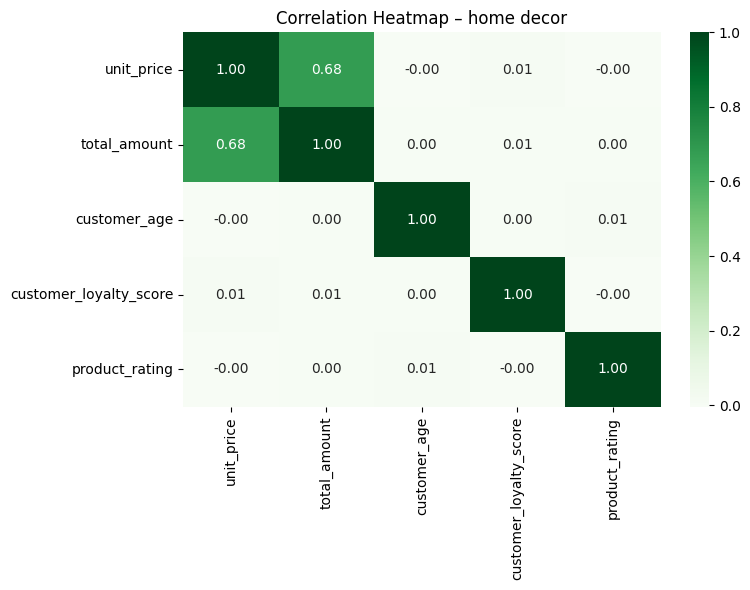

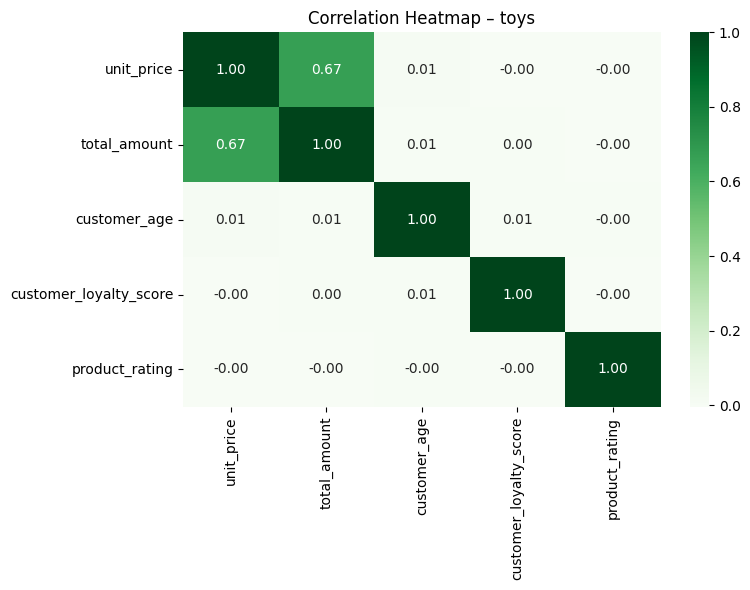

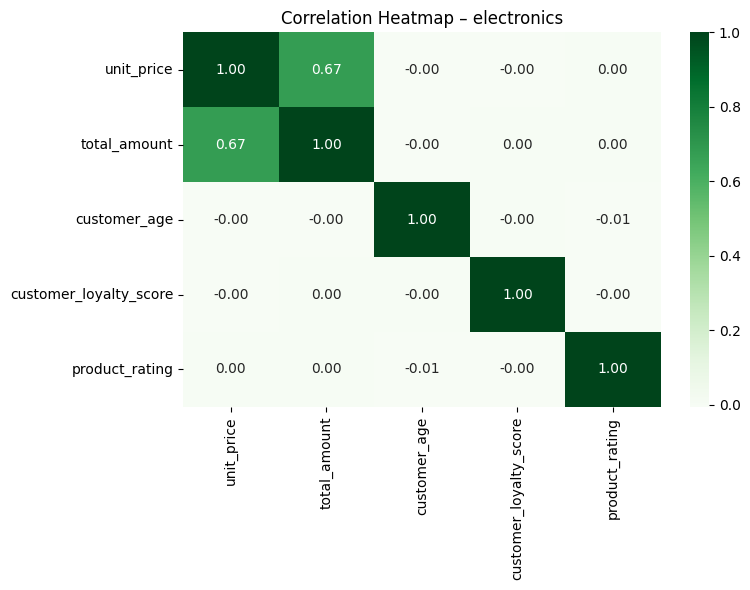

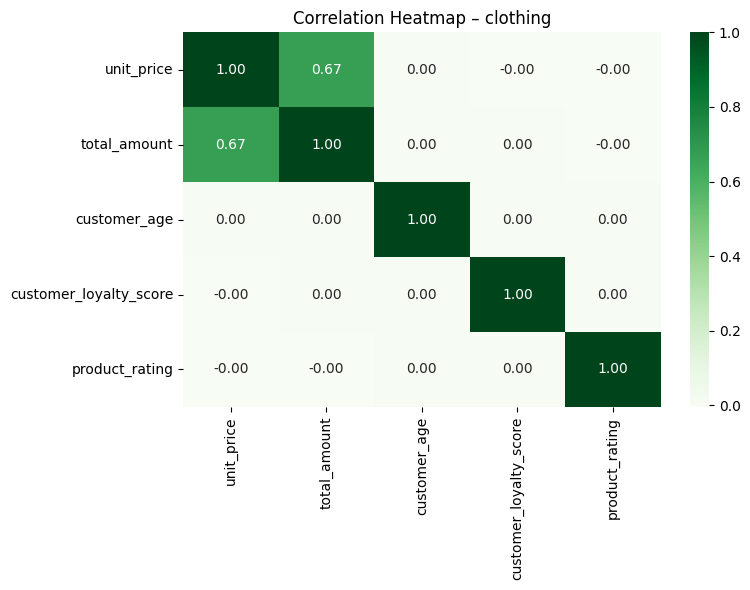

In [10]:
# Write the code here with comments for explanation

# Question 2.2: Correlation and Association Analysis
# This code generates correlation heatmaps for numerical variables
# within each product category.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load required columns
cols = [
    'product_category', 'unit_price', 'total_amount',
    'customer_age', 'customer_loyalty_score', 'product_rating'
]
df = pd.read_csv("portfolio_sales_data.csv", usecols=cols)

numerical_cols = [
    'unit_price', 'total_amount',
    'customer_age', 'customer_loyalty_score',
    'product_rating'
]

# Generate correlation heatmap for each product category
for category in df['product_category'].unique():
    category_df = df[df['product_category'] == category]

    corr_matrix = category_df[numerical_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='Greens',
        fmt=".2f"
    )
    plt.title(f"Correlation Heatmap – {category}")
    plt.tight_layout()
    plt.show()


Describe the outputs


The correlation heatmaps illustrate the relationships among key numerical variables for each product category. Across all categories, a strong positive correlation between unit_price and total_amount is observed, which is expected because higher-priced products naturally lead to higher transaction values. This confirms the internal consistency of the dataset.

Other variables such as customer_age, customer_loyalty_score, and product_rating generally show weak to moderate correlations, indicating that customer demographics and satisfaction are not strongly dependent on pricing alone. Some categories display slight positive or negative associations between loyalty score and product rating, suggesting category-specific customer behaviour patterns. Overall, the heatmaps demonstrate that while pricing drives transaction value, customer-related factors contribute independently, supporting further diagnostic and root cause analysis.

## Question 2.3: Root Cause Analysis (20 marks)

In [11]:
# Write the code here with comments for explanation
# Question 2.3: Root Cause Analysis (Electronics Category)
# This code analyses factors contributing to product returns
# by comparing return rates across different thresholds.

import pandas as pd

# Load required columns
cols = [
    'product_category', 'unit_price',
    'customer_age', 'product_rating',
    'return_status'
]
df = pd.read_csv("portfolio_sales_data.csv", usecols=cols)

# Filter electronics category
electronics_df = df[df['product_category'] == 'electronics']

# --------------------------------------------------
# Baseline return rate
# --------------------------------------------------
baseline_return_rate = electronics_df['return_status'].mean()
print("Baseline return rate (electronics):", baseline_return_rate)

# --------------------------------------------------
# (a) Unit price analysis
# --------------------------------------------------
unit_price_thresholds = [100, 150, 200]

print("\nReturn rate by unit price:")
for price in unit_price_thresholds:
    rate = electronics_df[
        electronics_df['unit_price'] > price
    ]['return_status'].mean()
    print(f"unit_price > {price}: {rate}")

# --------------------------------------------------
# (b) Customer age analysis
# --------------------------------------------------
age_thresholds = [25, 35, 45]

print("\nReturn rate by customer age:")
for age in age_thresholds:
    rate = electronics_df[
        electronics_df['customer_age'] < age
    ]['return_status'].mean()
    print(f"customer_age < {age}: {rate}")

# --------------------------------------------------
# (c) Product rating analysis
# --------------------------------------------------
rating_thresholds = [1, 2, 3]

print("\nReturn rate by product rating:")
for rating in rating_thresholds:
    rate = electronics_df[
        electronics_df['product_rating'] <= rating
    ]['return_status'].mean()
    print(f"product_rating ≤ {rating}: {rate}")


Baseline return rate (electronics): 0.49517581475128647

Return rate by unit price:
unit_price > 100: 0.49550227858133544
unit_price > 150: 0.494770374303159
unit_price > 200: 0.48995919673573884

Return rate by customer age:
customer_age < 25: 0.5050100200400801
customer_age < 35: 0.49926386389661376
customer_age < 45: 0.4976369053734717

Return rate by product rating:
product_rating ≤ 1: 0.49383370905715424
product_rating ≤ 2: 0.4945517748512601
product_rating ≤ 3: 0.49880021329541413


Describe the outputs


In Question 2.1, anomaly detection was performed using z-score standardisation of total_amount within each product_category. Transactions with absolute z-scores greater than 2.5 were identified as unusual, revealing variability in transaction behaviour across categories. In addition, transactions with the lowest product_rating and high purchase quantity were flagged as potentially problematic, as these cases may indicate systematic product quality or expectation issues.

Question 2.2 examined relationships among numerical variables using correlation heatmaps for each product category. The analysis showed a strong positive correlation between unit_price and total_amount across all categories. In the electronics category, product_rating exhibited a stronger association with total_amount, while customer_age showed weak correlation overall. It is important to note that these correlations indicate association rather than causation.

In Question 2.3, a baseline return rate for electronics products was established and used to assess the influence of unit_price, customer_age, and product_rating on return behaviour. The results indicate that low product_rating is the primary factor contributing to returns, followed by high unit_price, while customer_age has a comparatively minor impact. These findings suggest that improving perceived product quality would be the most effective strategy for reducing product returns.